# Predict Accessibility for EFS.fa

This notebook loads the sequences in `EFS.fa`, pads each sequence to a supported AlphaGenome input length, predicts ATAC accessibility across all available Homo sapiens tracks, summarizes the strongest accessibility signals, and visualizes a sampled subset of tracks.

In [10]:
from pathlib import Path
import os
import subprocess

from alphagenome import colab_utils
from alphagenome.models import dna_client
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams['figure.dpi'] = 120

In [ ]:
# Set the AlphaGenome API key from 1Password if it's not already set in the environment.
if 'ALPHA_GENOME_API_KEY' not in os.environ:
    os.environ['ALPHA_GENOME_API_KEY'] = subprocess.check_output(
        ['op', 'read', 'op://Private/AlphaGenome API Credential/credential'],
        text=True,
    ).strip()

dna_model = dna_client.create(colab_utils.get_api_key())

In [12]:
efs_path = Path('./EFS.fa')
supported_lengths = sorted(dna_client.SUPPORTED_SEQUENCE_LENGTHS.values())


def read_fasta(path: Path) -> list[tuple[str, str]]:
    records = []
    header = None
    chunks = []
    with path.open() as handle:
        for raw_line in handle:
            line = raw_line.strip()
            if not line:
                continue
            if line.startswith('>'):
                if header is not None:
                    records.append((header, ''.join(chunks).upper())) # Store the previous record
                header = line[1:] # Remove the '>' character
                chunks = [] # Reset chunks for the new record
            else:
                chunks.append(line) # Accumulate sequence lines

    if header is not None:
        records.append((header, ''.join(chunks).upper())) # Store the last record

    if not records:
        raise ValueError(f'No FASTA records found in {path}.')

    return records


def choose_supported_length(length: int) -> int:
    for supported_length in supported_lengths: # Find the smallest supported length that can accommodate the sequence
        if length <= supported_length:
            return supported_length
    raise ValueError(
        'Sequence is longer than the largest AlphaGenome-supported length: '
        f'{length} > {supported_lengths[-1]}'
    )


def pad_sequence(sequence: str) -> tuple[str, int, int, int]:
    # Validate that the sequence contains only valid bases (A, C, G, T, N)
    invalid_bases = sorted(set(sequence) - set('ACGTN'))
    if invalid_bases:
        raise ValueError(
            'Sequences must contain only A, C, G, T, or N. '
            f'Found invalid bases: {invalid_bases}'
        )

    # Pad the sequence with 'N' to the nearest supported length, centering the original sequence
    target_length = choose_supported_length(len(sequence))
    left_padding = (target_length - len(sequence)) // 2
    right_padding = target_length - len(sequence) - left_padding
    padded_sequence = 'N' * left_padding + sequence + 'N' * right_padding
    return padded_sequence, target_length, left_padding, left_padding + len(sequence)

In [13]:
records = read_fasta(efs_path)

prepared_records = []
for sequence_name, sequence in records:
    padded_sequence, model_length, insert_start, insert_end = pad_sequence(sequence)
    prepared_records.append(
        {
            'sequence_name': sequence_name,
            'original_length': len(sequence),
            'model_length': model_length,
            'insert_start': insert_start,
            'insert_end': insert_end,
            'padded_sequence': padded_sequence,
        }
    )

sequence_table = pd.DataFrame(prepared_records)
sequence_table[
    ['sequence_name', 'original_length', 'model_length', 'insert_start', 'insert_end']
].copy()

,sequence_name,original_length,model_length,insert_start,insert_end
0,MM-EFS-1,4398,16384,5993,10391
1,MM-EFS-2,4398,16384,5993,10391
2,MM-EFS-3,4398,16384,5993,10391
3,MM-EFS-4,4398,16384,5993,10391
4,MM-EFS-5,4398,16384,5993,10391
5,MM-EFS-6,4398,16384,5993,10391
6,MM-EFS-7,4398,16384,5993,10391
7,MM-EFS-8,4398,16384,5993,10391
8,MM-EFS-9,4398,16384,5993,10391
9,MM-EFS-10,4398,16384,5993,10391


## Predict ATAC Accessibility

Setting `ontology_terms=None` requests all available Homo sapiens ATAC ontologies exposed by AlphaGenome.

In [14]:
# Predict ATAC-seq signal for each sequence using the AlphaGenome DNA model
outputs = dna_model.predict_sequences(
    sequences=sequence_table['padded_sequence'].tolist(),
    organism=dna_client.Organism.HOMO_SAPIENS,
    requested_outputs=[dna_client.OutputType.ATAC],
    ontology_terms=None,
    progress_bar=True,
    max_workers=2,
    intervals=None,
)

# Extract ATAC-seq outputs from the model predictions
atac_outputs = [output.atac for output in outputs]

# Print result
{
    'num_sequences': len(atac_outputs),
    'first_output_shape': atac_outputs[0].values.shape,
    'first_output_resolution_bp': atac_outputs[0].resolution,
}

100%|██████████| 10/10 [00:01<00:00,  5.06it/s]


{'num_sequences': 10,
 'first_output_shape': (16384, 167),
 'first_output_resolution_bp': 1}

In [15]:
# Summarize the result. 
prediction_summary = sequence_table[
    ['sequence_name', 'original_length', 'model_length', 'insert_start', 'insert_end']
].copy()
prediction_summary['num_atac_tracks'] = [atac.num_tracks for atac in atac_outputs]
prediction_summary['num_bins'] = [atac.values.shape[0] for atac in atac_outputs]
prediction_summary['track_resolution_bp'] = [atac.resolution for atac in atac_outputs]

track_metadata = atac_outputs[0].metadata.reset_index(drop=True).copy()
track_metadata['track_index'] = track_metadata.index

prediction_summary

,sequence_name,original_length,model_length,insert_start,insert_end,num_atac_tracks,num_bins,track_resolution_bp
0,MM-EFS-1,4398,16384,5993,10391,167,16384,1
1,MM-EFS-2,4398,16384,5993,10391,167,16384,1
2,MM-EFS-3,4398,16384,5993,10391,167,16384,1
3,MM-EFS-4,4398,16384,5993,10391,167,16384,1
4,MM-EFS-5,4398,16384,5993,10391,167,16384,1
5,MM-EFS-6,4398,16384,5993,10391,167,16384,1
6,MM-EFS-7,4398,16384,5993,10391,167,16384,1
7,MM-EFS-8,4398,16384,5993,10391,167,16384,1
8,MM-EFS-9,4398,16384,5993,10391,167,16384,1
9,MM-EFS-10,4398,16384,5993,10391,167,16384,1


In [16]:
# Compute mean and max accessibility for each track and sequence, and compile into a single table
per_sequence_track_scores = []
for sequence_name, atac in zip(sequence_table['sequence_name'], atac_outputs, strict=True):
    score_table = track_metadata.copy()
    score_table['sequence_name'] = sequence_name # Add sequence name to the score table for this sequence
    score_table['mean_accessibility'] = atac.values.mean(axis=0) # Average accessibility across all bins for each track
    score_table['max_accessibility'] = atac.values.max(axis=0) # Maximum accessibility across all bins for each track
    per_sequence_track_scores.append(score_table)

# Combine the per-sequence track scores into a single DataFrame
track_scores = pd.concat(per_sequence_track_scores, ignore_index=True)
track_scores.head()

,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,data_source,endedness,genetically_modified,nonzero_mean,track_index,sequence_name,mean_accessibility,max_accessibility
0,CL:0000084 ATAC-seq,.,ATAC-seq,CL:0000084,T-cell,primary_cell,adult,encode,paired,False,0.739741,0,MM-EFS-1,0.027975,5.937500
1,CL:0000100 ATAC-seq,.,ATAC-seq,CL:0000100,motor neuron,in_vitro_differentiated_cells,adult,encode,paired,False,0.273136,1,MM-EFS-1,0.012755,2.578125
2,CL:0000236 ATAC-seq,.,ATAC-seq,CL:0000236,B cell,primary_cell,adult,encode,paired,False,4.700081,2,MM-EFS-1,0.031701,10.187500
3,CL:0000623 ATAC-seq,.,ATAC-seq,CL:0000623,natural killer cell,primary_cell,adult,encode,paired,False,0.938715,3,MM-EFS-1,0.024558,5.375000
4,CL:0000624 ATAC-seq,.,ATAC-seq,CL:0000624,"CD4-positive, alpha-beta T cell",primary_cell,adult,encode,paired,False,4.365206,4,MM-EFS-1,0.037145,10.125000


In [17]:
# Create a global ranking of tracks by mean and max accessibility, and include track metadata for interpretation
metadata_columns = [
    column
    for column in [
        'track_index',
        'name',
        'cell_type',
        'ontology_curie',
        'biosample_type',
        'developmental_stage',
        'assay',
    ]
    if column in track_metadata.columns
]

# Aggregate mean and max accessibility scores for each track across all sequences, merge with track metadata, and sort by accessibility
global_track_ranking = (
    track_scores.groupby('track_index', as_index=False)
    .agg(
        mean_accessibility=('mean_accessibility', 'mean'),
        max_accessibility=('max_accessibility', 'max'),
    )
    .merge(track_metadata[metadata_columns], on='track_index', how='left')
    .sort_values(['mean_accessibility', 'max_accessibility'], ascending=False)
    .reset_index(drop=True)
 )
global_track_ranking

,track_index,mean_accessibility,max_accessibility,name,ontology_curie,biosample_type
0,62,0.034283,7.343750,EFO:0002713 ATAC-seq,EFO:0002713,cell_line
1,6,0.030132,12.625000,CL:0000787 ATAC-seq,CL:0000787,primary_cell
2,56,0.030072,6.343750,EFO:0001187 ATAC-seq,EFO:0001187,cell_line
3,55,0.029671,3.968750,EFO:0001086 ATAC-seq,EFO:0001086,cell_line
4,4,0.028725,10.125000,CL:0000624 ATAC-seq,CL:0000624,primary_cell
...,...,...,...,...,...,...
162,41,0.011510,1.812500,CLO:0026253 ATAC-seq,CLO:0026253,cell_line
163,52,0.011236,2.234375,CLO:0027432 ATAC-seq,CLO:0027432,cell_line
164,1,0.010451,2.875000,CL:0000100 ATAC-seq,CL:0000100,in_vitro_differentiated_cells
165,69,0.009874,3.906250,EFO:0009747 ATAC-seq,EFO:0009747,cell_line


In [18]:
# For each sequence, identify the top 10 tracks by mean accessibility
sequence_level_top_tracks = (
    track_scores.sort_values(
        ['sequence_name', 'mean_accessibility'],
        ascending=[True, False],
    )
    .groupby('sequence_name') 
    .head(10) # Keep only the top 10 tracks for each sequence
    .reset_index(drop=True)
 )

prediction_summary.to_csv('efs_prediction_summary.csv', index=False)
track_scores.to_csv('efs_atac_track_scores.csv', index=False)
global_track_ranking.to_csv('efs_atac_global_track_ranking.csv', index=False)
sequence_level_top_tracks.to_csv('efs_atac_top_tracks_per_sequence.csv', index=False)

sequence_level_top_tracks

,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,data_source,endedness,genetically_modified,nonzero_mean,track_index,sequence_name,mean_accessibility,max_accessibility
0,EFO:0002713 ATAC-seq,.,ATAC-seq,EFO:0002713,Panc1,cell_line,adult,encode,paired,False,1.317396,62,MM-EFS-1,0.040902,6.56250
1,UBERON:0008971 ATAC-seq,.,ATAC-seq,UBERON:0008971,left colon,tissue,adult,encode,paired,False,0.675871,163,MM-EFS-1,0.040462,5.96875
2,CL:0000787 ATAC-seq,.,ATAC-seq,CL:0000787,memory B cell,primary_cell,adult,encode,paired,False,2.839230,6,MM-EFS-1,0.039521,12.62500
3,CL:0000625 ATAC-seq,.,ATAC-seq,CL:0000625,"CD8-positive, alpha-beta T cell",primary_cell,adult,encode,paired,False,4.313537,5,MM-EFS-1,0.038373,11.25000
4,CL:0000624 ATAC-seq,.,ATAC-seq,CL:0000624,"CD4-positive, alpha-beta T cell",primary_cell,adult,encode,paired,False,4.365206,4,MM-EFS-1,0.037145,10.12500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,CL:0000787 ATAC-seq,.,ATAC-seq,CL:0000787,memory B cell,primary_cell,adult,encode,paired,False,2.839230,6,MM-EFS-9,0.026209,7.90625
96,UBERON:0008367 ATAC-seq,.,ATAC-seq,UBERON:0008367,breast epithelium,tissue,adult,encode,paired,False,0.591131,159,MM-EFS-9,0.025818,3.00000
97,EFO:0002824 ATAC-seq,.,ATAC-seq,EFO:0002824,HCT116,cell_line,adult,encode,paired,False,1.531573,64,MM-EFS-9,0.024598,5.40625
98,CL:0000788 ATAC-seq,.,ATAC-seq,CL:0000788,naive B cell,primary_cell,adult,encode,paired,False,1.596229,7,MM-EFS-9,0.023965,6.43750


In [19]:
sequence_level_top_tracks.biosample_name.value_counts()

biosample_name
Panc1                                                   10
memory B cell                                           10
CD4-positive, alpha-beta T cell                         10
CD8-positive, alpha-beta T cell                          9
A549                                                     9
central memory CD8-positive, alpha-beta T cell           7
naive B cell                                             7
breast epithelium                                        6
naive thymus-derived CD4-positive, alpha-beta T cell     5
T-helper 17 cell                                         5
sciatic nerve                                            5
B cell                                                   3
HepG2                                                    3
HCT116                                                   3
effector memory CD8-positive, alpha-beta T cell          2
MCF-7                                                    2
left colon                               

## Visualize Sampled Tracks

The full ATAC output contains many tracks, so the plot below uses the highest-mean tracks across the EFS sequences and highlights the original insert span within the padded model input.

In [20]:
def make_track_label(row: pd.Series) -> str:
    # Create a human-readable label for a track by combining available metadata fields. 
    label_parts = [f"track {row['track_index']}"]
    for column in ['cell_type', 'name', 'ontology_curie', 'biosample_name']:
        value = row.get(column)
        if pd.notna(value) and value not in label_parts:
            label_parts.append(str(value))
    return ' | '.join(label_parts)

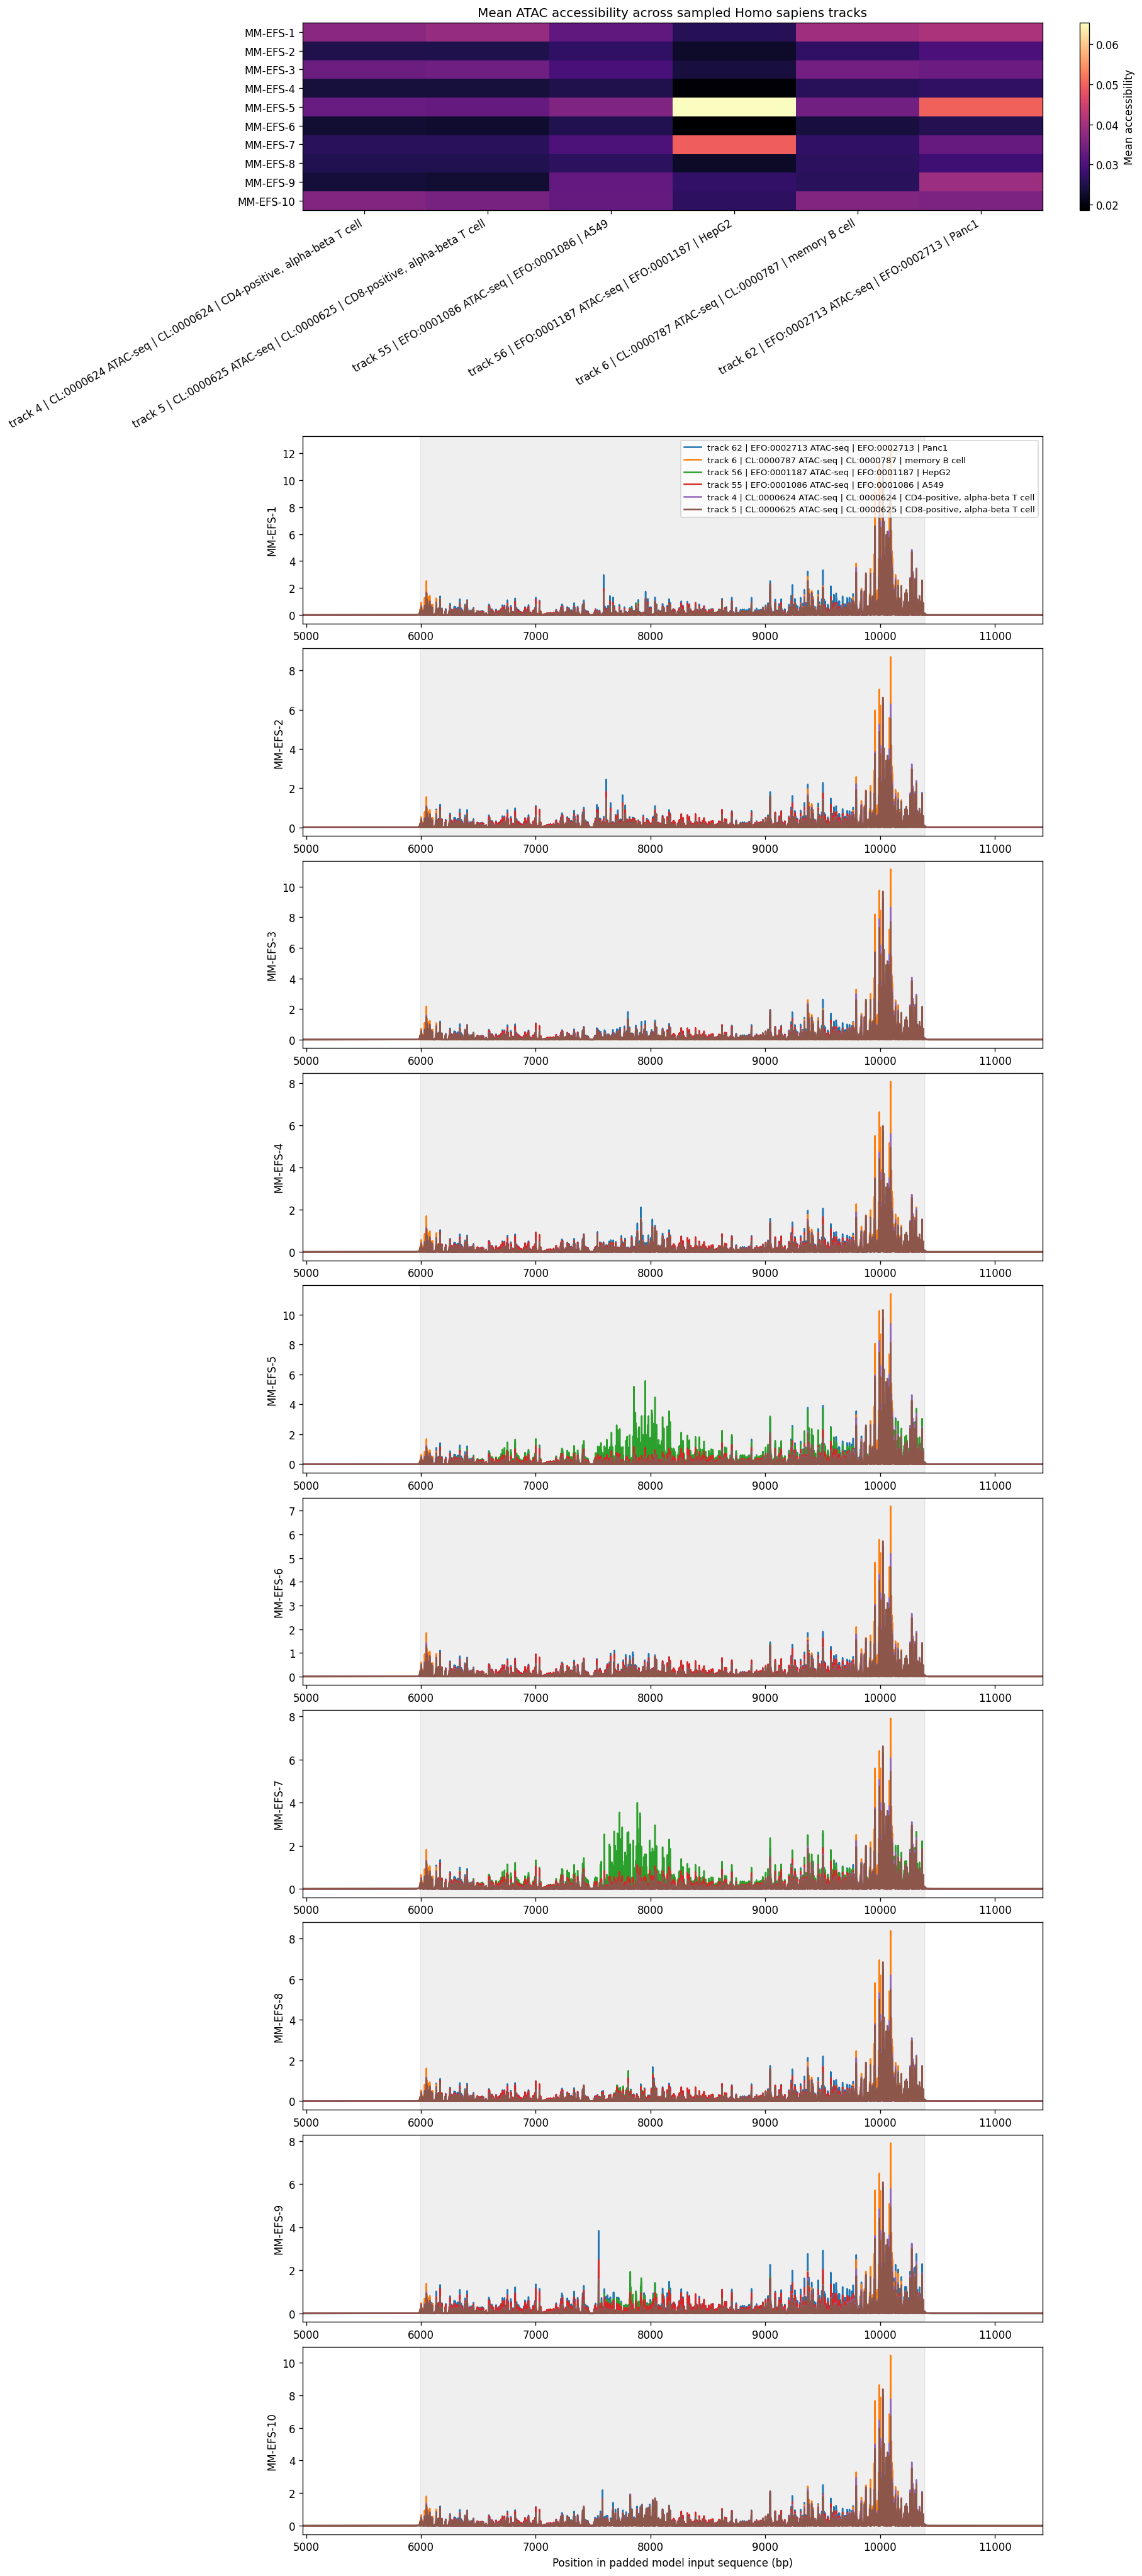

In [21]:
# Select the top tracks to visualize based on global ranking. 
sampled_track_indices = global_track_ranking.head(
    min(6, len(global_track_ranking))
)['track_index'].tolist()

sampled_track_rows = track_metadata.loc[sampled_track_indices].copy()
sampled_track_rows['plot_label'] = sampled_track_rows.apply(make_track_label, axis=1)

mean_heatmap = (
    track_scores[track_scores['track_index'].isin(sampled_track_indices)]
    .merge(
        sampled_track_rows[['track_index', 'plot_label']],
        on='track_index',
        how='left',
    )
    .pivot(index='sequence_name', columns='plot_label', values='mean_accessibility')
    .loc[sequence_table['sequence_name']]
 )

fig, axes = plt.subplots(
    nrows=len(sequence_table) + 1,
    ncols=1,
    figsize=(15, 3 * len(sequence_table) + 4),
    constrained_layout=True,
 )

heatmap_ax = axes[0]
heatmap = mean_heatmap.to_numpy(dtype=float)
image = heatmap_ax.imshow(heatmap, aspect='auto', cmap='magma')
heatmap_ax.set_xticks(np.arange(mean_heatmap.shape[1]))
heatmap_ax.set_xticklabels(mean_heatmap.columns, rotation=30, ha='right')
heatmap_ax.set_yticks(np.arange(mean_heatmap.shape[0]))
heatmap_ax.set_yticklabels(mean_heatmap.index)
heatmap_ax.set_title('Mean ATAC accessibility across sampled Homo sapiens tracks')
fig.colorbar(image, ax=heatmap_ax, label='Mean accessibility')

for axis_offset, (_, row) in enumerate(sequence_table.iterrows(), start=1):
    atac = atac_outputs[axis_offset - 1]
    ax = axes[axis_offset]
    x_positions = np.arange(atac.values.shape[0]) * atac.resolution

    for track_index, plot_label in zip(
        sampled_track_indices,
        sampled_track_rows['plot_label'],
        strict=True,
    ):
        ax.plot(x_positions, atac.values[:, track_index], linewidth=1.5, label=plot_label)

    ax.axvspan(row['insert_start'], row['insert_end'], color='lightgrey', alpha=0.35)
    window_start = max(0, row['insert_start'] - 1024)
    window_end = min(row['model_length'], row['insert_end'] + 1024)
    ax.set_xlim(window_start, window_end)
    ax.set_ylabel(row['sequence_name'])
    if axis_offset == 1:
        ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Position in padded model input sequence (bp)')
plt.show()